# Preprocessing Data and EDA

## Importing libaries

In [18]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import re #RegEx

## Loading Input datasets

Both datasets are collected from Kaggle. First we will perform EDA step.

In [2]:
spam_assassin_dataset = pd.read_csv('./data/spam_assassin.csv')
trec_email_dataset = pd.read_csv('./data/email_origin__trec2006.csv')

## Checking basic info likes samples amount, features amount in both datasets

### `spam_assassin_dataset`


In [ ]:
spam_assassin_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5796 non-null   str  
 1   target  5796 non-null   int64
dtypes: int64(1), str(1)
memory usage: 90.7 KB



In [5]:
trec_email_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 37822 entries, 0 to 37821
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   37822 non-null  int64
 1   origin  37822 non-null  str  
dtypes: int64(1), str(1)
memory usage: 591.1 KB


In [6]:
spam_assassin_dataset.value_counts(spam_assassin_dataset['target'])

target
0    3900
1    1896
Name: count, dtype: int64

In [7]:
trec_email_dataset.value_counts(trec_email_dataset['label'])

label
1    24912
0    12910
Name: count, dtype: int64

Since the labels in both datasets are defined differently:

In `spam_assassin_dataset`, 0 represents `HAM` and 1 represents `SPAM`.

In `trec_email_dataset`, 1 represents `HAM` and 0 represents `SPAM`.

We will use the `.map()` function in Pandas to align the label values in trec_email_dataset.

In [34]:
trec_email_dataset['label'] = trec_email_dataset['label'].map({1:0,0:1})

## Plotting class distribution using Bar chart

In [49]:
# Changing SpamAssassin feature `target` to label first
spam_assassin_dataset = spam_assassin_dataset.rename(columns={'target':'label'})

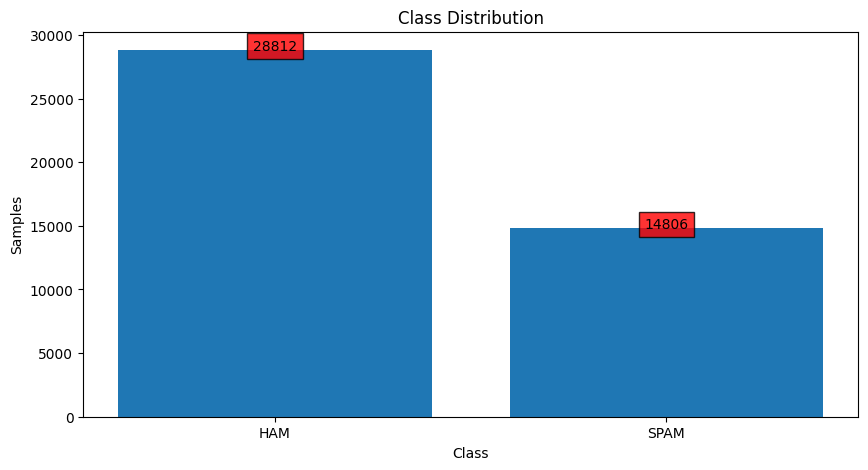

In [ ]:
# Plotting bar chart, using Matplotlib library
colors = sns.color_palette(palette='bright')
samples_data = pd.concat([trec_email_dataset['label'],spam_assassin_dataset['label']],ignore_index=True)

# Counting the frequency of SPAM/HAM labels to visualize the bar chart
label_counts = samples_data.value_counts()
labels = ['HAM','SPAM']


# Function to add labels inside a box
def add_labels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha='center', 
                 bbox=dict(facecolor='red', alpha=0.8))  # Adding a red box around text

x = ["Engineering", "BSc", "MBA", "Bcom", "BBA", "MSc"]
y = [9330, 4050, 3030, 5500, 8040, 4560]

# Setting figure size
plt.figure(figsize=(10, 5))

# Creating bar chart
plt.bar(labels, label_counts)

# Adding value labels
add_labels(labels, label_counts)

# Adding title and labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")

plt.show()


In [50]:
# Loading the aligned datasets, prepare for data preprocessing steps
trec_email_dataset.to_csv('./data/checkpoints/eda_trec_email_dataset.csv')
spam_assassin_dataset.to_csv('./data/checkpoints/eda_spam_assassin_email_dataset.csv')